## Libraries and env 

In [2]:
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt

In [3]:
from dotenv import load_dotenv
import os
from pathlib import Path

def load_environment():
    """Load environment variables and return them as a dictionary."""
    load_dotenv(Path("../utils/.env"))  # Loads .env from project root (works if run from notebook too)
    env_vars = {
        "IMAGE_FOLDER": os.getenv("IMAGE_FOLDER"),
        "EXTRACTEDDATASET_FOLDER": os.getenv("EXTRACTEDDATASET_FOLDER"),
        "DATASETS_FOLDER": os.getenv("DATASETS_FOLDER"),
        "ElevationDataset": os.getenv("ElevationDataset"),
        "LandCoverDataset": os.getenv("LandCoverDataset"),
        "GeoBoundaries": os.getenv("GeoBoundaries"),
        "EXTRACTEDELEVATION_FOLDER": os.getenv("EXTRACTEDELEVATION_FOLDER"),
        "EXTRACTEDLANDCOVER_FOLDER": os.getenv("EXTRACTEDLANDCOVER_FOLDER"),
        "EXTRACTEDGEOBOUNDARIES_FOLDER": os.getenv("EXTRACTEDGEOBOUNDARIES_FOLDER"),
        "CLEANEDDATASET_FOLDER": os.getenv("CLEANEDDATASET_FOLDER"),
        "CLEANEDELEVATION_FOLDER": os.getenv("CLEANEDELEVATION_FOLDER"),
        "CLEANEDLANDCOVER_FOLDER": os.getenv("CLEANEDLANDCOVER_FOLDER")
    }
    return env_vars

folders = load_environment()
image_folder = folders["IMAGE_FOLDER"]
extractedData_folder = folders["EXTRACTEDDATASET_FOLDER"]
datasets_folder = folders["DATASETS_FOLDER"]
landCover_folder = folders["LandCoverDataset"]
elevation_folder = folders["ElevationDataset"]
geoboundaries_folder = folders["GeoBoundaries"]
extracted_elevation_folder = folders["EXTRACTEDELEVATION_FOLDER"]
extracted_landcover_folder = folders["EXTRACTEDLANDCOVER_FOLDER"]
extracted_geo_boundaries_folder = folders["EXTRACTEDGEOBOUNDARIES_FOLDER"]
cleaned_dataset_folder = folders["CLEANEDDATASET_FOLDER"]
cleaned_elevation_folder = folders["CLEANEDELEVATION_FOLDER"]
cleaned_landcover_folder = folders["CLEANEDLANDCOVER_FOLDER"]


## read file

In [3]:
# reading Land Cover dataset geojspon file
landcover_gdf = gpd.read_file(f"{extracted_landcover_folder}/landcover_combined.geojson")


c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Several features with id = 1 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


 ## Head

In [ ]:
# viewing structure
landcover_gdf.head()

,id,gridcode,area,lcccode,geometry
0,4,210,6.228187e+06,7001 // 8001,"POLYGON ((6.41528 37.08696, 6.43103 37.0855, 6..."
1,2,210,6.242408e+06,7001 // 8001,"POLYGON ((7.18084 37.07917, 7.17998 37.08091, ..."
2,1,210,1.482995e+06,7001 // 8001,"POLYGON ((7.37137 37.08194, 7.3709 37.08717, 7..."
3,8,50,4.590841e+08,21497-121340,"POLYGON ((6.12361 36.68472, 6.12361 36.69306, ..."
4,13,210,6.371533e+06,7001 // 8001,"POLYGON ((6.26181 37.02361, 6.26193 37.02514, ..."


In [ ]:
#  column types
landcover_gdf.dtypes

id             int32
gridcode       int32
area         float64
lcccode       object
geometry    geometry
dtype: object

In [ ]:
# length of the geodataframe
print("length of geodataframe",len(landcover_gdf))
# how many unique ids are there?
print("unique id",landcover_gdf['id'].nunique())
# how many unique land cover types are there?
print("unique lcccode",landcover_gdf['lcccode'].nunique())
# how many unique gridcode
print("unique gridcode",landcover_gdf['gridcode'].nunique())


length of geodataframe 438513
unique id 386454
unique lcccode 22
unique gridcode 22


In [ ]:
# showing where id is duplicated
duplicated_ids = landcover_gdf[landcover_gdf.duplicated(subset=['id'], keep=False)]
print(duplicated_ids.sort_values(by='id'))  # sorting for better readability


           id  gridcode      area       lcccode  \
2           1       210  0.000150  7001 // 8001   
386454      1       210  0.000317  7001 // 8001   
386456      2        30  0.000015  0004 // 0003   
1           2       210  0.000633  7001 // 8001   
5           3        50  0.001325  21497-121340   
...       ...       ...       ...           ...   
53112   52057        20  0.001127   0003 / 0004   
438509  52058       200  0.000013          0011   
50503   52058        20  0.000031   0003 / 0004   
50710   52059        30  0.000039  0004 // 0003   
438512  52059       201  0.000054          6001   

                                                 geometry  
2       POLYGON ((7.37137 37.08194, 7.3709 37.08717, 7...  
386454  POLYGON ((8.89941 37.52083, 8.90027 37.52481, ...  
386456  POLYGON ((8.94583 37.53472, 8.94861 37.53472, ...  
1       POLYGON ((7.18084 37.07917, 7.17998 37.08091, ...  
5       POLYGON ((7.20417 37.05972, 7.20972 37.05972, ...  
...                        

its not real duplicates

we will drop the column only because its not meaningful for the model

In [21]:
# checking rows where theres a nan column at least inside landcover_gdf
nan_rows = landcover_gdf[landcover_gdf.isnull().any(axis=1)]
print(nan_rows)


Empty GeoDataFrame
Columns: [id, gridcode, area, lcccode, geometry]
Index: []


not a one nan row

In [ ]:
# checking if gridcode and lcccode have one to one relationship
unique_pairs = landcover_gdf[["gridcode", "lcccode"]].drop_duplicates()
print(f"Unique (GRIDCODE, LCCCODE) pairs: {len(unique_pairs)}")
print(unique_pairs)


Unique (GRIDCODE, LCCCODE) pairs: 22
        gridcode                           lcccode
0            210                      7001 // 8001
3             50                      21497-121340
6            130                             21450
9             30                      0004 // 0003
10            14                             11498
18            70                      21499-121340
27            20                       0003 / 0004
57           110     21446 // 21450-121340 / 21454
86           100                       21497-15045
203          150                    20049 // 20058
325           41      21496-121340 // 21497-129401
400          170  41638-60686-R2 // 41898-60686-R2
433          134                             21518
464          120           21454 // 21446 // 21450
731          190                              0010
1002         201                              6001
1091          16                    11490 // 11494
1639         200                             

we should consider dropping one of those probably gridcode since its not bringing additionnal information

## Piechart of lcccode 

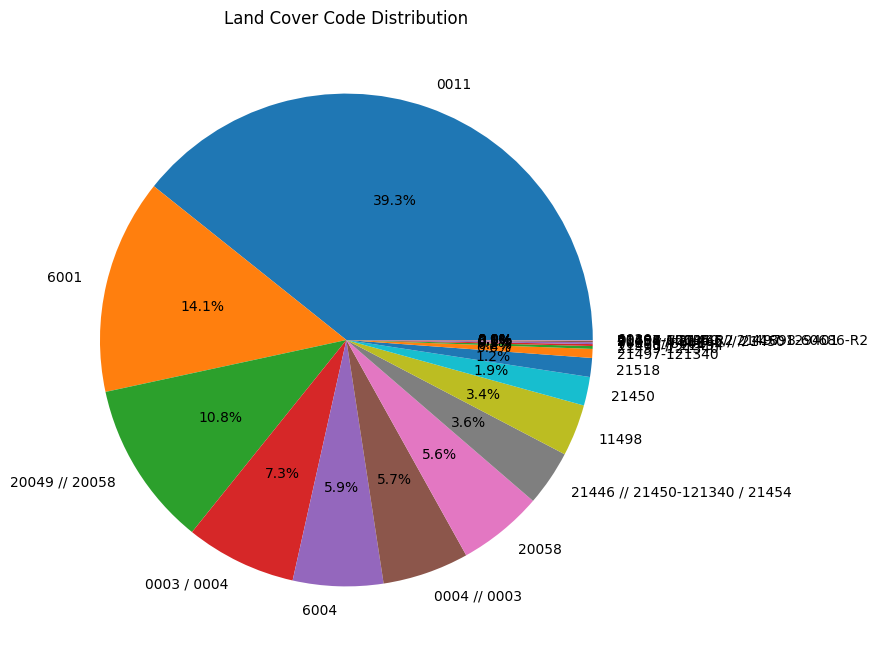

In [ ]:
# pie chart of lcccode
landcover_gdf['lcccode'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(8, 8))
plt.title('Land Cover Code Distribution')
plt.ylabel('')
plt.show()


## Land cover map

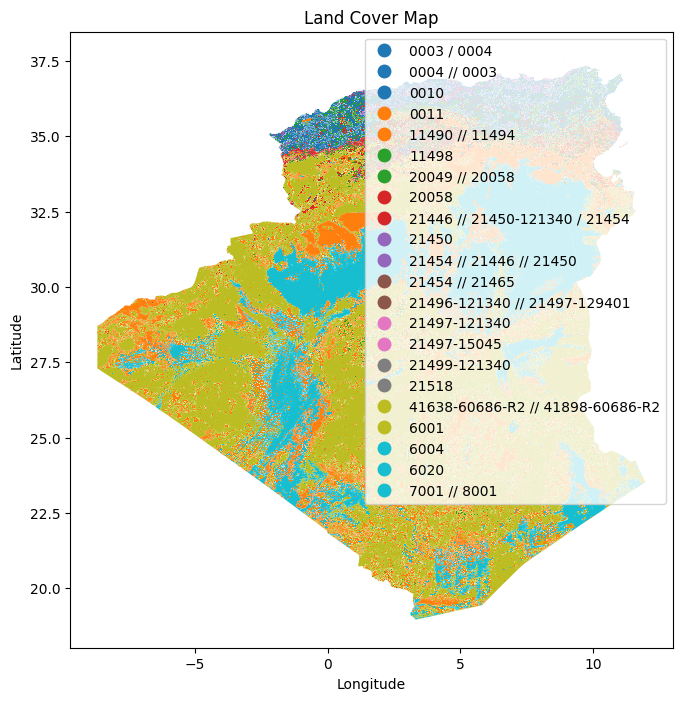

In [ ]:
#  showing land cover map
landcover_gdf.plot(column='lcccode', legend=True, figsize=(12, 8))
plt.title('Land Cover Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


## Relationship between area and land cover type

C:\Users\moous\AppData\Local\Temp\ipykernel_62468\3630520702.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  landcover_gdf['area'] = landcover_gdf.geometry.area


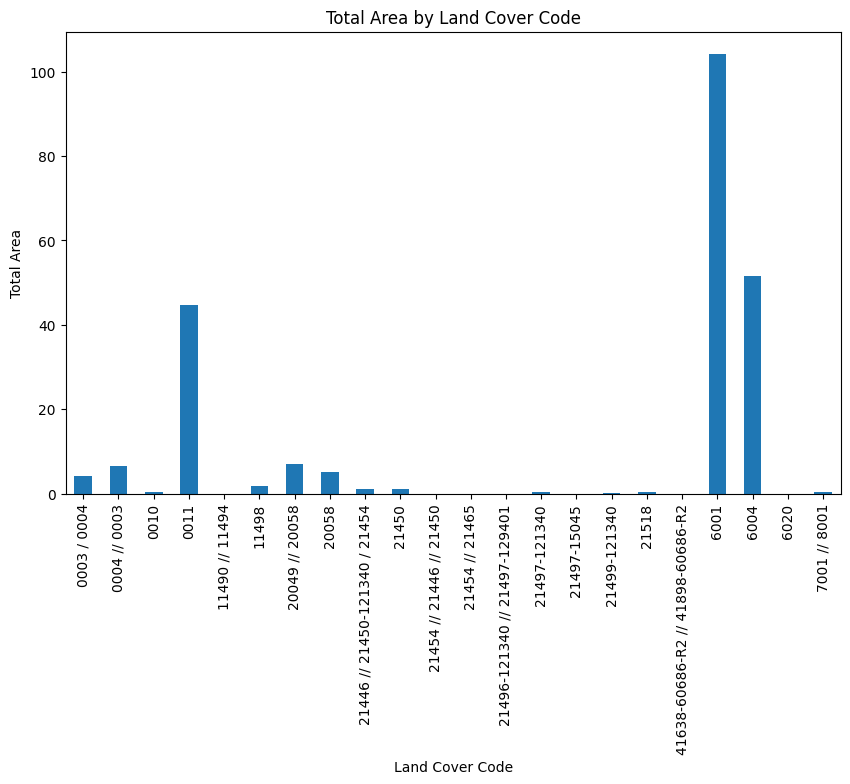

In [ ]:
# displaying area and lcccode relationship
landcover_gdf['area'] = landcover_gdf.geometry.area
landcover_gdf.groupby('lcccode')['area'].sum().plot.bar(figsize=(10, 6))
plt.title('Total Area by Land Cover Code')
plt.xlabel('Land Cover Code')
plt.ylabel('Total Area')
plt.show()

🌍 1. Interpreting 7001 // 8001

This likely indicates that a polygon (or raster cell group) contains mixed or uncertain land cover types — meaning it falls between two classification codes:

7001 → first class (for example, “Shrubland”)

8001 → second class (for example, “Bare / Sparse vegetation”)

// → separator meaning “between”, “mixed with”, or “transition zone between two classes”.

So this entry doesn’t mean a mathematical range but a land cover mixture between class 7001 and 8001.

might consider to:
- split into 2 columns to avoid losing information 
- or keep only one to avoid null columns values for unique lcccode

## i need to search in meta data the legend for each lcccode and gridcode

In [4]:
# accessing the excel file containing lcccode legends
lcccode_legend = pd.read_excel(f"{landCover_folder}/Algeria/globcover_LCCS_legend_africa.xls")

# accessing excel file containing gridcode legends
gridcode_legend = pd.read_excel(f"{landCover_folder}/Algeria/globcover_legend.xls")

#### lcccode

In [5]:
# displaying lcccode legend
print("LCCCODE Legend:")
print(lcccode_legend)

LCCCODE Legend:
                            LC  LPos  \
0                 9Mixed Class   1.0   
1                        Error   1.0   
2           0Dichotomous Phase   1.0   
3                 9Mixed Class   1.0   
4                          NaN   NaN   
5                 9Mixed Class   1.0   
6                          NaN   NaN   
7           0Dichotomous Phase   1.0   
8           0Dichotomous Phase   1.0   
9     1Consolidated Bare Areas   1.0   
10  2Unconsolidated Bare Areas   1.0   
11                       Error   1.0   
12                9Mixed Class   1.0   
13                9Mixed Class   1.0   
14                 5Grasslands   1.0   
15                9Mixed Class   1.0   
16                       Error   1.0   
17                9Mixed Class   1.0   
18                9Mixed Class   1.0   
19                       Error   1.0   
20                9Mixed Class   1.0   
21                9Mixed Class   1.0   
22                9Mixed Class   1.0   
23                9Mixed

In [6]:
# make it a dataframe
lcccode_legend_df = pd.DataFrame(lcccode_legend)

#  print all columns
print(lcccode_legend_df.columns)

lcccode_legend_df.head()

# saving the dataframe into a folder as a dataframe
lcccode_legend_df.to_csv(f"{extracted_landcover_folder}/lcccode_legend.csv", index=False)




Index(['LC', 'LPos', 'LCCCode', 'LCCMode', 'LCCLevel', 'LCCOwnLabel',
       'LCCOwnDescr', 'LCCLabel', 'MapCode'],
      dtype='object')


In [7]:
# get column LC distinct values
print(lcccode_legend_df['LC'].unique())

['9Mixed Class' 'Error' '0Dichotomous Phase' nan
 '1Consolidated Bare Areas' '2Unconsolidated Bare Areas' '5Grasslands'
 '2Woodland' '6Sparse Vegetation']


as seen some contain error, others nan valyes

In [8]:
# display lcccode where LC error
lcccode_error = lcccode_legend_df[lcccode_legend_df['LC'] == 'Error'] 

# fetching the lcccode values with errors
error_lccodes = lcccode_error['LCCCode'].unique().tolist()
print("LCCODEs with 'Error' in LC:", error_lccodes)

LCCODEs with 'Error' in LC: ['41739-R1', '6020', '41724-60686-R1', '11498', '21497-121340', '21499-121340', '21497-15045', '21497-129398', '21450', '21518', '21454-121340']


In [9]:
# checking if our landcover geodataframe contains any of these error lccodes
error_entries = landcover_gdf[landcover_gdf['lcccode'].isin(error_lccodes)]
print("Entries in landcover_gdf with error LCCODEs:")
print(error_entries)
# checking length
print("Number of entries with error LCCODEs:", len(error_entries))

Entries in landcover_gdf with error LCCODEs:
           id  gridcode          area       lcccode  \
3           8        50  4.590841e+08  21497-121340   
5           3        50  1.308172e+07  21497-121340   
6          14       130  1.903570e+06         21450   
7          17        50  3.691677e+05  21497-121340   
10          7        14  1.522787e+05         11498   
...       ...       ...           ...           ...   
431734  45363        14  2.387460e+05         11498   
431736  45375        14  7.958310e+05         11498   
432261  45864        14  5.575500e+05         11498   
432333  45932        14  2.389730e+05         11498   
432343  45959        14  1.593240e+05         11498   

                                                 geometry  
3       POLYGON ((6.12361 36.68472, 6.12361 36.69306, ...  
5       POLYGON ((7.20417 37.05972, 7.20972 37.05972, ...  
6       POLYGON ((6.44583 37.07917, 6.44583 37.08194, ...  
7       POLYGON ((6.40694 37.08194, 6.40694 37.08472, 

that's a lot of rows --> keep in mind in preprocessing if should be removed or replaced

lets check the meaning of the lcccode

In [10]:
# print LCCOwnLabel for those error entries
print("LCCOwnLabel unique values if lcccode is error:")
print(lcccode_error['LCCOwnLabel'].unique())



LCCOwnLabel unique values if lcccode is error:
['Closed to open broadleaved forest on temporarely flooded land - fresh water'
 'Salt hardpans'
 'Closed to open broadleaved  forest on temporarely floodedland - fresh water.'
 'Rainfed cropland' 'Closed (>40%) broadleaved decidous forest'
 'Closed (>40%) needeleaved evergreen forest'
 'Closed to open (>15%) mixed broadleaved decidous and needleaved evergreen forerst'
 'Closed (>40%) mixed broadleaved decidous and needleavedevergreen forest'
 'Closed to open shrubland'
 'Closed to open broadleaved decidous shrubland' 'Closed grassland']


so its not actual errors

In [ ]:
# creating a dictionary to map lcccode to LCCOwnLabel
lcccode_to_label = dict(zip(lcccode_legend_df['LCCCode'], lcccode_legend_df['LCCOwnLabel']))
    
# print lcccode_to_label dictionary
print("LCCCODE to LCCOwnLabel mapping:")
for code, label in lcccode_to_label.items():
    print(f"{code}: {label}")

# print length
print("Number of LCCCODE to LCCOwnLabel mappings:", len(lcccode_to_label))


LCCCODE to LCCOwnLabel mapping:
41653-R1 // 41653-R2: Closedto open broadleavedforest regularly flooded (semi-permanently or temporarily) - fresh or brakish water
41739-R1: Closed to open broadleaved forest on temporarely flooded land - fresh water
0007: Closed to open grassland or woody vegetation on regularlyflooded or waterloggedsoil - Fresh, brakish or saline water
41521-R1 // 41521-R2 // 41597-R1 // 41597-R2: Closed to open woody vegetation on regularly flooded or waterlogged soil - Fresh or brakish water
nan: nan
42347-R1 // 42347-R2 // 42349-R1 // 42349-R2: Closed to open grassland on regularly flooded orwaterlogged soil - Fresh or brakish water
0010: Artficial surfaces and associated areas
0011: Bare areas
6001: Consolidated bare areas
6004: Non - consolidated bare areas
6020: Salt hardpans
8005 // 8008: Permanent snow and ice
7001 // 8001: Water bodies
20038: Open grassland
41638-60686-R2 // 41898-60686-R2: Closed broadleaved forest or shrubland permanently flooded - brakish w

there's 46 different lcccodes, but in our geojson there's only 22 so lets filter

In [16]:
#  lets keep only the lcccode in lccode_to_label that are present in landcover_gdf
filtered_lcccode_to_label = {code: label for code, label in lcccode_to_label.items() if code in landcover_gdf['lcccode'].unique()}
# checking length
print("Number of filtered LCCCODE to LCCOwnLabel mappings:", len(filtered_lcccode_to_label))

# saving the filtered dictionary --- IGNORE ---
import pickle
with open(f"{extracted_landcover_folder}/lcccode_to_label.pkl", "wb") as f:
    pickle.dump(filtered_lcccode_to_label, f)

Number of filtered LCCCODE to LCCOwnLabel mappings: 22


In [18]:
# print lcccode_to_label dictionary
print("LCCCODE to LCCOwnLabel mapping:")
for code, label in filtered_lcccode_to_label.items():
    print(f"{code}: {label}")

LCCCODE to LCCOwnLabel mapping:
0010: Artficial surfaces and associated areas
0011: Bare areas
6001: Consolidated bare areas
6004: Non - consolidated bare areas
6020: Salt hardpans
7001 // 8001: Water bodies
41638-60686-R2 // 41898-60686-R2: Closed broadleaved forest or shrubland permanently flooded - brakish water
11498: Rainfed cropland
11490 // 11494: Rainfed trees and scrub crops
0003 / 0004: Mosaic cropland vegetation
0004 // 0003: Mosaic vegetation / cropland
21496-121340 // 21497-129401: Closed (>40%) broadleaved evergreen or semidecidous forest
21497-121340: Closed (>40%) broadleaved decidous forest
21499-121340: Closed (>40%) needeleaved evergreen forest
21497-15045: Closed to open (>15%) mixed broadleaved decidous and needleaved evergreen forerst
21446 // 21450-121340 / 21454: Mosaic forest or shrubland/grassland
21454 // 21446 // 21450: Mosaic grassland/forest or shrubland
21450: Closed to open shrubland
21518: Closed to open broadleaved decidous shrubland
21454 // 21465: Cl

i need to find a way to transform the lcccode column for the ai model --> simplify into main landcover types

In [6]:
# mapping dictionary that contains main types 
lcc_highlevel_mapping = {
    # Artificial surfaces
    "0010": "Artificial surfaces",
    # Bare lands
    "0011": "Bare lands",
    "6001": "Bare lands",
    "6004": "Bare lands",
    "6020": "Bare lands",

    # Water bodies
    "7001 // 8001": "Water bodies",

    # Sparse or Flooded Vegetation
    "41638-60686-R2 // 41898-60686-R2": "Vegetation",

    # Croplands
    "11498": "Croplands",
    "11490 // 11494": "Croplands",
    "0003 / 0004": "Croplands",
    "0004 // 0003": "Croplands",

    # Forests
    "21497-121340": "Forests",
    "21499-121340": "Forests",
    "21497-15045": "Forests",
    '21496-121340 // 21497-129401': "Forests",

    # Shrublands / Grasslands
    "21446 // 21450-121340 / 21454": "Grasslands",
    "21454 // 21446 // 21450": "Grasslands",
    "21450": "Grasslands",
    "21518": "Grasslands",

    # Sparse vegetation (also fits the last group)
    "21454 // 21465": "Vegetation",
    "20049 // 20058": "Vegetation",
    "20058": "Vegetation",
}

print(len(lcc_highlevel_mapping))

# save the high level mapping dictionary --- IGNORE ---
import pickle
with open(f"{extracted_landcover_folder}/lcc_highlevel_mapping.pkl", "wb") as f:
    pickle.dump(lcc_highlevel_mapping, f)
    


22


#### gridcode

In [13]:

# displaying gridcode legend
print("\nGRIDCODE Legend:")
print(gridcode_legend)


GRIDCODE Legend:
    Value                                              Label  Red  Green  Blue
0      11  Post-flooding or irrigated croplands (or aquatic)  170    240   240
1      14                                  Rainfed croplands  255    255   100
2      20  Mosaic cropland (50-70%) / vegetation (grassla...  220    240   100
3      30  Mosaic vegetation (grassland/shrubland/forest)...  205    205   102
4      40  Closed to open (>15%) broadleaved evergreen or...    0    100     0
5      50   Closed (>40%) broadleaved deciduous forest (>5m)    0    160     0
6      60  Open (15-40%) broadleaved deciduous forest/woo...  170    200     0
7      70  Closed (>40%) needleleaved evergreen forest (>5m)    0     60     0
8      90  Open (15-40%) needleleaved deciduous or evergr...   40    100     0
9     100  Closed to open (>15%) mixed broadleaved and ne...  120    130     0
10    110  Mosaic forest or shrubland (50-70%) / grasslan...  140    160     0
11    120  Mosaic grassland (50-70

this proves that gridcode is a redundant column and has the same information as lcccode --> to be dropped